# Phishing URL Classification Notebook
Feature engineering for traditional machine learning models (SVM, Naive Bayes, Light GBM etc).
Character level embedding for deep learning models (RNN, CNN, LSTM, BiLSTM)

In [ ]:
# Install dependencies
!pip install shap tqdm pandas matplotlib numpy scikit-learn seaborn lightgbm catboost xgboost transformers accelerate bitsandbytes

import matplotlib.pyplot as plt, pandas as pd, numpy as np, seaborn as sns
import re, socket, time, joblib, torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, precision_recall_curve, average_precision_score

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelEncoder
from keras.preprocessing.sequence import pad_sequences

from lightgbm import LGBMClassifier

from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig, BertModel
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from datetime import datetime
from zoneinfo import ZoneInfo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 46.6 MB/s eta 0:00:00


## Data Loading and Feature Extraction

Total URLs: 822010
Phishing: 394982
Benign: 427028
Phishing %: 48.05%
Benign %: 51.95%


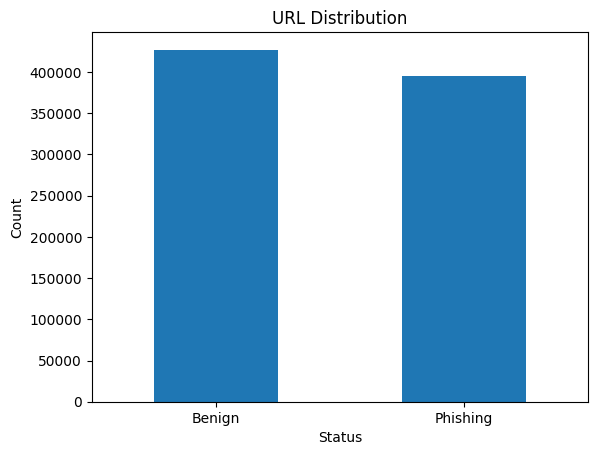

In [ ]:
df = pd.read_csv('new_data_urls.csv')
df['status'] = df['status'].map({0: 'Phishing', 1: 'Benign'})

print(f"Total URLs: {len(df)}")
print(f"Phishing: {(df['status'] == 'Phishing').sum()}")
print(f"Benign: {(df['status'] == 'Benign').sum()}")
print(f"Phishing %: {(df['status'] == 'Phishing').sum() / len(df) * 100:.2f}%")
print(f"Benign %: {(df['status'] == 'Benign').sum() / len(df) * 100:.2f}%")
df['status'].value_counts().sort_index()
df['url_length'] = df['url'].str.len()
df['url_length'].describe()
df.groupby('status')['url_length'].describe()
df['status'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('URL Distribution')
plt.xticks(rotation=0)
plt.show()

In [ ]:
def extract_domain(url):
    try:
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        domain = urlparse(url).netloc
        return domain if domain else url.split('/')[0]
    except:
        return url.split('/')[0].split('?')[0]

def has_ip(url):
    return int(bool(re.search(r'\d+\.\d+\.\d+\.\d+', url)))

def has_at(url):
    return int('@' in url)

def url_length_short(url):
    return int(len(url) < 54)

def count_slash(url):
    return url.count('/')

def has_https(url):
    return int('https' in url.lower())

shortening_services = ['bit.ly', 'tinyurl', 'goo.gl', 't.co', 'ow.ly', 'is.gd', 'buff.ly', 'adf.ly', 'bl.ink', 'lnkd.in']
def is_shortened(url):
    return int(any(s in url.lower() for s in shortening_services))

def has_dash_separator(domain):
    return int('-' in domain)

def has_dns(domain):
    try:
        socket.gethostbyname(domain)
        return 1
    except:
        return 0

def count_dots(url):
    return url.count('.')

def count_digits(url):
    return sum(c.isdigit() for c in url)

def count_special_chars(url):
    return sum(not c.isalnum() for c in url)

def extract_tld(domain):
    try:
        parts = domain.split('.')
        return parts[-1] if len(parts) > 1 else ''
    except:
        return ''

def is_tld_com(tld):
    return int(tld == 'com')

def is_tld_org(tld):
    return int(tld == 'org')

def is_tld_net(tld):
    return int(tld == 'net')

def is_tld_edu(tld):
    return int(tld == 'edu')

def is_tld_gov(tld):
    return int(tld == 'gov')

def tld_length(tld):
    return len(tld)

def subdomain_count(domain):
    return len(domain.split('.')) - 2 if len(domain.split('.')) > 2 else 0

def subdomain_length(domain):
    parts = domain.split('.')
    return len(parts[0]) if len(parts) > 2 else 0

def extract_path(url):
    try:
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        return urlparse(url).path
    except:
        return ''

def path_length(url):
    return len(extract_path(url))

def param_count(url):
    try:
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        query = urlparse(url).query
        return len(query.split('&')) if query else 0
    except:
        return 0

def has_file_extension(url):
    path = extract_path(url)
    return int(bool(re.search(r'\.(html|php|asp|aspx|jsp|exe|zip)$', path)))

def domain_digit_count(domain):
    return sum(c.isdigit() for c in domain)

suspicious_keywords = ['client', 'verify', 'login', 'secure', 'account', 'update', 'confirm', 'banking', 'signin']
def has_suspicious_keyword(url):
    return int(any(kw in url.lower() for kw in suspicious_keywords))

def domain_entropy(domain):
    import math
    prob = [domain.count(c) / len(domain) for c in set(domain)]
    return -sum([p * math.log2(p) for p in prob if p > 0])

def has_port(url):
    try:
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        port = urlparse(url).port
        return int(port is not None)
    except:
        return 0

def url_depth(url):
    path = extract_path(url)
    return path.count('/')

df['domain'] = df['url'].apply(extract_domain)
df['tld'] = df['domain'].apply(extract_tld)
df['has_ip'] = df['url'].apply(has_ip)
df['has_at'] = df['url'].apply(has_at)
df['url_short'] = df['url'].apply(url_length_short)
df['slash_count'] = df['url'].apply(count_slash)
df['has_https'] = df['url'].apply(has_https)
df['is_shortened'] = df['url'].apply(is_shortened)
df['dash_in_domain'] = df['domain'].apply(has_dash_separator)
df['dot_count'] = df['url'].apply(count_dots)
df['digit_count'] = df['url'].apply(count_digits)
df['special_char_count'] = df['url'].apply(count_special_chars)
df['tld_com'] = df['tld'].apply(is_tld_com)
df['tld_org'] = df['tld'].apply(is_tld_org)
df['tld_net'] = df['tld'].apply(is_tld_net)
df['tld_edu'] = df['tld'].apply(is_tld_edu)
df['tld_gov'] = df['tld'].apply(is_tld_gov)
df['tld_length'] = df['tld'].apply(tld_length)
df['subdomain_count'] = df['domain'].apply(subdomain_count)
df['subdomain_length'] = df['domain'].apply(subdomain_length)
df['path_length'] = df['url'].apply(path_length)
df['param_count'] = df['url'].apply(param_count)
df['has_file_ext'] = df['url'].apply(has_file_extension)
df['domain_digits'] = df['domain'].apply(domain_digit_count)
df['has_suspicious'] = df['url'].apply(has_suspicious_keyword)
df['entropy'] = df['domain'].apply(domain_entropy)
df['has_port'] = df['url'].apply(has_port)
df['url_depth'] = df['url'].apply(url_depth)
print(f"Extracted {len(df)} URLs with {len([c for c in df.columns if c not in ['url', 'status', 'domain', 'tld']])} features")
display(df.head())

Extracted 822010 URLs with 27 features


,url,status,url_length,domain,tld,has_ip,has_at,url_short,slash_count,has_https,...,subdomain_count,subdomain_length,path_length,param_count,has_file_ext,domain_digits,has_suspicious,entropy,has_port,url_depth
0,0000111servicehelpdesk.godaddysites.com,Phishing,39,0000111servicehelpdesk.godaddysites.com,com,0,0,1,0,0,...,1,22,0,0,0,7,0,4.045286,0,0
1,000011accesswebform.godaddysites.com,Phishing,36,000011accesswebform.godaddysites.com,com,0,0,1,0,0,...,1,19,0,0,0,6,0,3.974938,0,0
2,00003.online,Phishing,12,00003.online,online,0,0,1,0,0,...,0,0,0,0,0,5,0,2.751629,0,0
3,0009servicedeskowa.godaddysites.com,Phishing,35,0009servicedeskowa.godaddysites.com,com,0,0,1,0,0,...,1,18,0,0,0,4,0,3.943289,0,0
4,000n38p.wcomhost.com,Phishing,20,000n38p.wcomhost.com,com,0,0,1,0,0,...,1,7,0,0,0,5,0,3.546439,0,0


In [ ]:
#df.to_csv('extracted_url_features.csv', index=False)

In [ ]:
# # Deep Learning Models: RNN, CNN, LSTM, BiLSTM
RND = 42
np.random.seed(RND)
torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

# class CharCNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim=32, num_classes=2):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
#         self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
#         self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
#         self.pool = nn.MaxPool1d(kernel_size=2)
#         self.fc1 = nn.Linear(128, 64)
#         self.dropout = nn.Dropout(0.3)
#         self.fc2 = nn.Linear(64, num_classes)

#     def forward(self, x):
#         x = self.embedding(x)                # (batch, seq_len, embed_dim)
#         x = x.permute(0, 2, 1)               # (batch, embed_dim, seq_len)
#         x = torch.relu(self.conv1(x))
#         x = self.pool(x)                     # (batch, 64, seq_len/2)
#         x = torch.relu(self.conv2(x))
#         x = torch.max(x, dim=2)[0]           # global max-pool  (batch, 128)
#         x = torch.relu(self.fc1(x))
#         x = self.dropout(x)
#         x = self.fc2(x)
#         return x

# class CharRNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim=32, hidden_dim=64, num_classes=2, num_layers=1, dropout=0.3):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

#         self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
#                             batch_first=True, dropout=dropout)
#         self.fc1 = nn.Linear(hidden_dim, 64)
#         self.dropout = nn.Dropout(dropout)
#         self.fc2 = nn.Linear(64, num_classes)

#     def forward(self, x):
#         x = self.embedding(x)                 # (batch, seq_len, embed_dim)
#         out, (hn, cn) = self.lstm(x)
#         h = hn[-1]                             # last layer hidden state
#         x = torch.relu(self.fc1(h))
#         x = self.dropout(x)
#         x = self.fc2(x)
#         return x

# class CharLSTM(nn.Module):
#     def __init__(self, vocab_size, embed_dim=32, hidden_dim=32, num_classes=2, num_layers=2, dropout=0.3):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
#         self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
#         self.fc1 = nn.Linear(hidden_dim, 32)
#         self.dropout = nn.Dropout(dropout)
#         self.fc2 = nn.Linear(32, num_classes)
#     def forward(self, x):
#         x = self.embedding(x)                 # (batch, seq_len, embed_dim)
#         out, (hn, cn) = self.lstm(x)
#         h = hn[-1]                            # (batch, hidden_dim)
#         x = torch.relu(self.fc1(h))
#         x = self.dropout(x)
#         x = self.fc2(x)                       # logits
#         return x

# class CharBiLSTM(nn.Module):
#     def __init__(self, vocab_size, embed_dim=32, hidden_dim=32, num_classes=2, num_layers=1, dropout=0.3):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
#         self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True,
#                             bidirectional=True, dropout=dropout)
#         self.fc = nn.Linear(hidden_dim * 2, 32)
#         self.dropout = nn.Dropout(dropout)
#         self.out = nn.Linear(32, num_classes)
#     def forward(self, x):
#         x = self.embedding(x)
#         out, (hn, cn) = self.lstm(x)
#         # For bidirectional, hn shape = (num_layers*2, batch, hidden_dim)
#         # take last layer both directions concatenated
#         if hn.shape[0] % 2 == 0:
#             h = torch.cat([hn[-2], hn[-1]], dim=1)  # (batch, hidden*2)
#         else:
#             h = hn[-1]
#         x = torch.relu(self.fc(h))
#         x = self.dropout(x)
#         x = self.out(x)  # logits
#         return x

# # 4. TRAINING FUNCTION WITH TQDM
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# def train_dl_model(model, train_loader, val_loader=None, epochs=20, lr=1e-3,
#                         patience=5,
#                         grad_clip=1.0,
#                         desc_prefix="Model",
#                         verbose=True):
#     model = model.to(device)
#     criterion = nn.CrossEntropyLoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

#     best_state = None
#     best_loss = np.inf
#     wait = 0
#     start_time = time.time()

#     for epoch in range(1, epochs + 1):
#         model.train()
#         running_loss = 0.0
#         loop = tqdm(train_loader, desc=f"{desc_prefix} Epoch {epoch}/{epochs}", leave=False)
#         for X_batch, y_batch in loop:
#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device)
#             # label sanity checks
#             if y_batch.max().item() >= model.fc2.out_features if hasattr(model, 'fc2') else False:
#                 pass  # handled below generically; not all models have fc2 attr
#             # universal assertions
#             if y_batch.dtype != torch.long:
#                 y_batch = y_batch.long()
#             assert y_batch.max().item() < 10000  # a soft sanity upper bound to catch bad encodings quickly (not strict)
#             assert y_batch.min().item() >= 0

#             optimizer.zero_grad()
#             outputs = model(X_batch)
#             # More sanity: outputs shape last dim equals number of classes
#             assert outputs.dim() >= 2 and outputs.size(-1) >= 2
#             loss = criterion(outputs, y_batch)
#             loss.backward()
#             # gradient clipping
#             torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
#             optimizer.step()
#             running_loss += loss.item()
#             loop.set_postfix(train_loss=loss.item())

#         avg_train_loss = running_loss / max(1, len(train_loader))

#         # validation loss
#         val_loss = avg_train_loss
#         if val_loader is not None:
#             model.eval()
#             running_val = 0.0
#             with torch.no_grad():
#                 for Xv, yv in val_loader:
#                     Xv = Xv.to(device)
#                     yv = yv.to(device)
#                     outv = model(Xv)
#                     lv = criterion(outv, yv)
#                     running_val += lv.item()
#             val_loss = running_val / max(1, len(val_loader))

#         scheduler.step(val_loss)

#         if val_loss < best_loss:
#             best_loss = val_loss
#             best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#             wait = 0
#         else:
#             wait += 1
#             if wait >= patience:
#                 if verbose:
#                     tqdm.write(f"{desc_prefix}: Early stopping at epoch {epoch} (patience={patience})")
#                 break

#         if verbose:
#             tqdm.write(f"{desc_prefix} Epoch {epoch}: train_loss={avg_train_loss:.4f} val_loss={val_loss:.4f}")

#     train_time = time.time() - start_time
#     if best_state is not None:
#         model.load_state_dict(best_state)

#     # evaluation on val_loader (if provided) else on train_loader
#     eval_loader = val_loader if val_loader is not None else train_loader
#     model.eval()
#     y_pred = []
#     y_true = []
#     inference_start = time.time()
#     with torch.no_grad():
#         loop = tqdm(eval_loader, desc=f"Evaluating {desc_prefix}", leave=False)
#         for Xb, yb in loop:
#             Xb = Xb.to(device)
#             out = model(Xb)
#             preds = torch.argmax(out, dim=1).cpu().numpy()
#             y_pred.extend(preds)
#             y_true.extend(yb.numpy())
#     inference_time = time.time() - inference_start

#     return np.array(y_true), np.array(y_pred), train_time, inference_time, model


# def cross_val_char_model(model_class, X_array, y_array, model_kwargs=None, n_splits=5, epochs=10, batch_size=32, dl_type='char'):
#     model_kwargs = model_kwargs or {}
#     skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RND)
#     accs, f1s, precs, recs = [], [], [], []
#     fold = 0
#     for train_idx, val_idx in skf.split(X_array, y_array):
#         fold += 1
#         tqdm.write(f"Char CV fold {fold}/{n_splits}")
#         X_tr = torch.tensor(X_array[train_idx], dtype=torch.long)
#         X_val = torch.tensor(X_array[val_idx], dtype=torch.long)
#         y_tr = torch.tensor(y_array[train_idx], dtype=torch.long)
#         y_val = torch.tensor(y_array[val_idx], dtype=torch.long)

#         train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
#         val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

#         model = model_class(**model_kwargs)
#         y_true_fold, y_pred_fold, _, _, _ = train_dl_model(model, train_loader, val_loader, epochs=epochs, lr=1e-3, patience=3, desc_prefix=f"CV Fold {fold}", verbose=False)
#         accs.append(accuracy_score(y_true_fold, y_pred_fold))
#         f1s.append(f1_score(y_true_fold, y_pred_fold, pos_label=1))
#         precs.append(precision_score(y_true_fold, y_pred_fold, pos_label=1))
#         recs.append(recall_score(y_true_fold, y_pred_fold, pos_label=1))

#     return {
#         'CV Accuracy': np.mean(accs),
#         'CV Accuracy Std': np.std(accs),
#         'CV F1': np.mean(f1s),
#         'CV Precision': np.mean(precs),
#         'CV Recall': np.mean(recs)
#     }


In [ ]:
# #Optimized Char-BERT
# # This iteration accepts num_hidden_layers and num_attention_heads as constructor arguments

# class CharBERTClassifier(nn.Module):
#     def __init__(self, vocab_size, hidden_size=256, num_labels=2, max_len=200, num_hidden_layers=6, num_attention_heads=8):
#         super().__init__()

#         # Build a BERT config for character input
#         config = BertConfig(
#             vocab_size=vocab_size,          # your char vocabulary
#             hidden_size=hidden_size,
#             intermediate_size=hidden_size * 4,
#             max_position_embeddings=max_len,
#             num_hidden_layers=num_hidden_layers,
#             num_attention_heads=num_attention_heads,
#             type_vocab_size=1,
#             num_labels=num_labels
#         )

#         # Load the BERT model from config (random init)
#         self.bert = BertForSequenceClassification(config)

#     def forward(self, input_ids, attention_mask, labels=None): # Add labels=None to the forward signature
#         # Pass labels directly to the BERT model
#         return self.bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)


# def create_attention_mask(batch):
#     return (batch != 0).long()

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# def train_char_bert_model(model, train_loader, test_loader, epochs=5, lr=2e-5):
#     optimizer = AdamW(model.parameters(), lr=lr)
#     model.train()
#     model.to(device)

#     start_train = time.time()

#     for epoch in range(epochs):
#         epoch_loss = 0
#         pbar = tqdm(train_loader, desc=f"BERT Epoch {epoch+1}/{epochs}", leave=False)

#         for batch_x, batch_y in pbar:
#             batch_x, batch_y = batch_x.to(device), batch_y.to(device)

#             attention_mask = (batch_x != 0).long()
#             model.zero_grad()

#             outputs = model(
#                 input_ids=batch_x,
#                 attention_mask=attention_mask,
#                 labels=batch_y
#             )

#             loss = outputs.loss
#             loss.backward()
#             optimizer.step()

#             epoch_loss += loss.item()
#             pbar.set_postfix({"loss": f"{epoch_loss/len(train_loader):.4f}"})

#     train_time = time.time() - start_train

#     model.eval()
#     y_true, y_pred = [], []

#     start_inf = time.time()
#     with torch.no_grad():
#         pbar = tqdm(test_loader, desc="BERT Evaluation", leave=False)

#         for batch_x, batch_y in pbar:
#             batch_x, batch_y = batch_x.to(device), batch_y.to(device)
#             attention_mask = (batch_x != 0).long()

#             outputs = model(input_ids=batch_x, attention_mask=attention_mask)
#             preds = torch.argmax(outputs.logits, dim=1)

#             y_true.extend(batch_y.cpu().numpy())
#             y_pred.extend(preds.cpu().numpy())

#     inf_time = time.time() - start_inf

#     return np.array(y_true), np.array(y_pred), train_time, inf_time, model


# #exclude this!
# def evaluate_char_bert(model, test_loader):
#     model.eval()
#     preds, true = [], []

#     with torch.no_grad():
#         for batch_x, batch_y in tqdm(test_loader, desc="Evaluating", leave=False):
#             batch_x, batch_y = batch_x.to(device), batch_y.to(device)
#             attention_mask = create_attention_mask(batch_x)

#             outputs = model(input_ids=batch_x, attention_mask=attention_mask)
#             logits = outputs.logits
#             pred = torch.argmax(logits, dim=1).cpu().numpy()

#             preds.extend(pred)
#             true.extend(batch_y.cpu().numpy())

#     return true, preds

In [ ]:
label_map = {'Phishing': 0, 'Benign': 1}
inv_label_map = {v: k for k, v in label_map.items()}

SAMPLE_SIZE = 0.1

feature_cols = ['has_ip', 'has_at', 'url_short', 'slash_count', 'has_https', 'is_shortened',
                'dash_in_domain', 'dot_count', 'digit_count', 'special_char_count', 'url_length',
                'tld_com', 'tld_org', 'tld_net', 'tld_edu', 'tld_gov', 'tld_length',
                'subdomain_count', 'subdomain_length', 'path_length', 'param_count', 'has_file_ext',
                'domain_digits', 'has_suspicious', 'entropy', 'has_port', 'url_depth']

missing = set(feature_cols + ['url', 'status']) - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

# Filter out rows where 'status' is NaN before proceeding with feature and label extraction
df_cleaned = df.dropna(subset=['status']).copy()

# X_full = df_cleaned[feature_cols].astype(float)
# y_full_raw = df_cleaned['status'].astype(str)

X = df_cleaned[feature_cols]
y = df_cleaned['status']

if SAMPLE_SIZE is not None:
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=SAMPLE_SIZE, stratify=y, random_state=42)
    print(f"Using stratified sample: {len(X_sample)} rows\n")
else:
    X_sample, y_sample = X, y

# map status to ints
y_sample_int = y_sample.map(label_map)
if y_sample_int.isna().any():
    bad = y_sample[y_sample_int.isna()].unique()
    raise ValueError(f"Found status values not in label_map: {bad}")

# final feature train/test split for tabular models
X_train, X_test, y_train_int, y_test_int = train_test_split(X_sample, y_sample_int.values, # Use y_sample_int here
                                                            test_size=0.3, stratify=y_sample_int.values,
                                                            random_state=RND)

# keep string versions for ML model branches that accept strings (e.g., for direct comparison)
y_train_str = pd.Series(y_train_int).map(inv_label_map).values # Reconstruct original string labels for ML models if needed
y_test_str = pd.Series(y_test_int).map(inv_label_map).values # Reconstruct original string labels for ML models if needed


# # Character-level encoding for URLs (Char-LSTM / Char-BiLSTM)
# # Build vocabulary from the sample used for training/testing (keeps consistent mapping)
# all_urls = df_cleaned.loc[X_sample.index, 'url'].astype(str).values # Changed df to df_cleaned
# all_chars = sorted(list(set(''.join(all_urls))))
# # reserve 0 for padding; indices start at 1
# char_to_idx = {c: i + 1 for i, c in enumerate(all_chars)}
# idx_to_char = {i: c for c, i in char_to_idx.items()}
# vocab_size = len(char_to_idx) + 1  # +1 for padding index 0

# max_seq_len = 200  # adjust according to your URL lengths; higher -> more memory
# def encode_url(url):
#     return [char_to_idx.get(c, 0) for c in str(url)]

# # Encode & pad for entire df sample (so CV uses the same arrays)
# X_urls_full = X_sample.index.to_series().map(lambda i: encode_url(df_cleaned.at[i, 'url'])) # Changed df to df_cleaned
# X_urls_padded = pad_sequences(X_urls_full.tolist(), maxlen=max_seq_len, padding='post', truncating='post')
# y_urls_full = y_sample_int.values  # Use the integer-mapped y_sample_int

# # split into train/test aligned with X_train/X_test indices
# # We used X_sample earlier; now reconstruct train/test split by indices
# train_idx_mask = X_sample.index.isin(X_train.index)
# # But we used train_test_split earlier; easier to compute train/test splits again from X_urls_padded:
# X_urls = X_urls_padded
# y_urls = y_urls_full
# # To keep consistency with tabular split, produce same train/test by re-splitting using same random_state + stratify
# X_urls_train, X_urls_test, y_urls_train, y_urls_test = train_test_split(
#     X_urls, y_urls, test_size=0.3, stratify=y_urls, random_state=RND
# )

# # Convert to tensors for DataLoaders
# X_train_tensor_urls = torch.tensor(X_urls_train, dtype=torch.long)
# X_test_tensor_urls = torch.tensor(X_urls_test, dtype=torch.long)
# y_train_tensor_urls = torch.tensor(y_urls_train, dtype=torch.long)
# y_test_tensor_urls = torch.tensor(y_urls_test, dtype=torch.long)


# # Prepare tabular tensors for CNN/RNN (Option A)
# # CNN: (batch, channels=1, seq_len=features)
# # RNN (feature-as-timesteps): (batch, seq_len=features, input_size=1)
# X_train_np = X_train.values.astype(np.float32)
# X_test_np = X_test.values.astype(np.float32)
# # Use the same integer labels as above
# y_train_tab = np.array(y_train_int, dtype=np.int64)
# y_test_tab = np.array(y_test_int, dtype=np.int64)

# X_train_cnn = torch.tensor(X_train_np).unsqueeze(1)   # (N,1,features)
# X_test_cnn = torch.tensor(X_test_np).unsqueeze(1)
# X_train_rnn = torch.tensor(X_train_np).unsqueeze(2)   # (N,features,1)
# X_test_rnn = torch.tensor(X_test_np).unsqueeze(2)
# y_train_tensor_tab = torch.tensor(y_train_tab, dtype=torch.long)
# y_test_tensor_tab = torch.tensor(y_test_tab, dtype=torch.long)

y_train_original = y_sample.loc[X_train.index].copy() # Ensure original labels are strings if models need them
y_test_original = y_sample.loc[X_test.index].copy() # Ensure original labels are strings if models need them

results = []
predictions = {}
trained_models = {}

models_improved = {
    #  'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RND),
    #  'Naive Bayes': GaussianNB(),
       'Decision Tree': DecisionTreeClassifier(random_state=RND, max_depth=10),
       'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RND, n_jobs=-1),
    #  'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=RND),
    #  'K Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
       'CatBoost Classifier': CatBoostClassifier(verbose=0, random_state=RND)
    #  'Support Vector Machine': SVC(probability=True, random_state=RND),
    #  'XGBoost Classifier': XGBClassifier(n_estimators=100, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=RND, n_jobs=-1),
    #  'Multi-layer Perceptron': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=RND),
    #  'LightGBM': LGBMClassifier(random_state=RND, n_jobs=-1, verbose=-1)
}


# Keep original y_train and y_test for models that don't require label encoding
# y_train_original and y_test_original are already set to string versions

for name, model in tqdm(models_improved.items(), desc="Training ML Models", total=len(models_improved)):
    current_y_train = y_train_original
    current_y_test = y_test_original

    if name in ("Gradient Boosting", "K Nearest Neighbors", "CatBoost Classifier", "XGBoost Classifier", "LightGBM"):
        label_encoder = LabelEncoder()
        current_y_train = label_encoder.fit_transform(y_train_original)
        current_y_test = label_encoder.transform(y_test_original) # Encode test set as well for evaluation

    tqdm.write(f"Training {name}...")
    start_time = time.time()
    model.fit(X_train, current_y_train)
    train_time = time.time() - start_time

    tqdm.write(f"Evaluating {name}...")
    start_time = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start_time

    tqdm.write(f"Cross-validating {name}...")
    cv_scores = cross_val_score(model, X_train, current_y_train, cv=5, scoring='accuracy', n_jobs=-1)

    predictions[name] = y_pred
    trained_models[name] = model

    # Convert predictions back to original labels for evaluation if encoding was applied
    if name in ("Gradient Boosting", "K Nearest Neighbors", "CatBoost Classifier", "XGBoost Classifier", "LightGBM"):
        y_pred = label_encoder.inverse_transform(y_pred)
        current_y_test = label_encoder.inverse_transform(current_y_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(current_y_test, y_pred),
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Precision': precision_score(current_y_test, y_pred, pos_label='Benign'),
        'Recall': recall_score(current_y_test, y_pred, pos_label='Benign'),
        'F1-Score': f1_score(current_y_test, y_pred, pos_label='Benign'),
        'Train Time (s)': round(train_time, 3),
        'Inference Time (s)': round(inference_time, 3)
    })
    tqdm.write(f"✓ {name} complete (F1: {f1_score(current_y_test, y_pred, pos_label='Benign'):.4f})\n")

print("All ML models trained!")


# # 6. TRAIN DEEP LEARNING MODELS
# batch_size = 32
# num_classes = 2
# input_dim = X_train.shape[1]

# #DataLoaders
# train_loader_char = DataLoader(TensorDataset(X_train_tensor_urls, y_train_tensor_urls),
#     batch_size=batch_size, shuffle=True)

# test_loader_char = DataLoader(TensorDataset(X_test_tensor_urls, y_test_tensor_urls),
#     batch_size=batch_size, shuffle=False)

#  # CNN
# tqdm.write("Training CharCNN...")
# char_cnn = CharCNN(vocab_size=vocab_size, embed_dim=32, num_classes=2)
# y_true, y_pred, train_time, inf_time, trained_cnn = train_dl_model(
#      char_cnn, train_loader_char, test_loader_char, epochs=10, lr=1e-3)

# y_true_str = np.array([inv_label_map[i] for i in y_true])
# y_pred_str = np.array([inv_label_map[i] for i in y_pred])
# results.append({
#      'Model': 'CharCNN',
#      'Accuracy': accuracy_score(y_true, y_pred),
#      'CV Accuracy': np.nan,
#      'CV Std': np.nan,
#      'Precision': precision_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'Recall': recall_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'F1-Score': f1_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'Train Time (s)': round(train_time, 3),
#      'Inference Time (s)': round(inf_time, 3)
#  })

# predictions['CharCNN'] = np.array([inv_label_map[i] for i in y_pred])
# trained_models['CharCNN'] = trained_cnn
# tqdm.write(f"✓ CharCNN complete (F1: {f1_score(y_true_str, y_pred_str, pos_label='Benign'):.4f})")

#  # RNN
# tqdm.write("Training CharRNN...")
# char_rnn = CharRNN(vocab_size=vocab_size, embed_dim=32, hidden_dim=64, num_classes=2)
# y_true, y_pred, train_time, inf_time, trained_rnn = train_dl_model(
#      char_rnn, train_loader_char, test_loader_char, epochs=10, lr=1e-3)

# y_true_str = np.array([inv_label_map[i] for i in y_true])
# y_pred_str = np.array([inv_label_map[i] for i in y_pred])

# results.append({
#      'Model': 'CharRNN',
#      'Accuracy': accuracy_score(y_true, y_pred),
#      'CV Accuracy': np.nan,
#      'CV Std': np.nan,
#      'Precision': precision_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'Recall': recall_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'F1-Score': f1_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'Train Time (s)': round(train_time, 3),
#      'Inference Time (s)': round(inf_time, 3)
# })
# predictions['CharRNN'] = np.array([inv_label_map[i] for i in y_pred])
# trained_models['CharRNN'] = trained_rnn
# tqdm.write(f"✓ CharRNN complete (F1:  {f1_score(y_true_str, y_pred_str, pos_label='Benign'):.4f})")

# # Char-LSTM: Cross-validate then final train
# tqdm.write("Cross-validating Char-LSTM...")
# char_model_kwargs = {'vocab_size': vocab_size, 'embed_dim': 32, 'hidden_dim': 64, 'num_classes': num_classes, 'num_layers': 2, 'dropout': 0.3}
# char_cv = cross_val_char_model(CharLSTM, X_urls, y_urls, model_kwargs=char_model_kwargs, n_splits=5, epochs=8, batch_size=batch_size)

# tqdm.write("Training final Char-LSTM...")
# train_loader_urls = DataLoader(TensorDataset(X_train_tensor_urls, y_train_tensor_urls), batch_size=batch_size, shuffle=True)
# test_loader_urls = DataLoader(TensorDataset(X_test_tensor_urls, y_test_tensor_urls), batch_size=batch_size, shuffle=False)
# char_lstm = CharLSTM(**char_model_kwargs)
# y_true, y_pred, train_time, inf_time, char_trained = train_dl_model(char_lstm, train_loader_urls, test_loader_urls,
#                                                                          epochs=20, lr=1e-3, patience=5, grad_clip=1.0,
#                                                                          desc_prefix="Char-LSTM", verbose=True)
# y_true_str = np.array([inv_label_map[i] for i in y_true])
# y_pred_str = np.array([inv_label_map[i] for i in y_pred])
# results.append({
#      'Model': 'Char-LSTM',
#      'Accuracy': accuracy_score(y_true, y_pred),
#      'CV Accuracy': char_cv['CV Accuracy'],
#      'CV Std': char_cv['CV Accuracy Std'],
#      'Precision': precision_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'Recall': recall_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'F1-Score': f1_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'Train Time (s)': round(train_time, 3),
#      'Inference Time (s)': round(inf_time, 3)
# })
# predictions['Char-LSTM'] = np.array([inv_label_map[i] for i in y_pred])
# trained_models['Char-LSTM'] = char_trained
# tqdm.write(f"✓ Char-LSTM complete (F1: {f1_score(y_true_str, y_pred_str, pos_label='Benign'):.4f})")

#  # Char-BiLSTM: Cross-validate then final train
# tqdm.write("Cross-validating Char-BiLSTM...")
# bilstm_model_kwargs = {'vocab_size': vocab_size, 'embed_dim': 32, 'hidden_dim': 32, 'num_classes': num_classes, 'num_layers': 1, 'dropout': 0.3}
# bilstm_cv = cross_val_char_model(CharBiLSTM, X_urls, y_urls, model_kwargs=bilstm_model_kwargs, n_splits=5, epochs=8, batch_size=batch_size)

# tqdm.write("Training final Char-BiLSTM...")
# char_bilstm = CharBiLSTM(**bilstm_model_kwargs)
# y_true, y_pred, train_time, inf_time, bilstm_trained = train_dl_model(char_bilstm, train_loader_urls, test_loader_urls,
#                                                                            epochs=20, lr=1e-3, patience=5, grad_clip=1.0,
#                                                                            desc_prefix="Char-BiLSTM", verbose=True)
# y_true_str = np.array([inv_label_map[i] for i in y_true])
# y_pred_str = np.array([inv_label_map[i] for i in y_pred])
# results.append({
#      'Model': 'Char-BiLSTM',
#      'Accuracy': accuracy_score(y_true, y_pred),
#      'CV Accuracy': bilstm_cv['CV Accuracy'],
#      'CV Std': bilstm_cv['CV Accuracy Std'],
#      'Precision': precision_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'Recall': recall_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'F1-Score': f1_score(y_true_str, y_pred_str, pos_label='Benign'),
#      'Train Time (s)': round(train_time, 3),
#      'Inference Time (s)': round(inf_time, 3)
# })
# predictions['Char-BiLSTM'] = np.array([inv_label_map[i] for i in y_pred])
# trained_models['Char-BiLSTM'] = bilstm_trained
# tqdm.write(f"✓ Char-BiLSTM complete (F1: {f1_score(y_true_str, y_pred_str, pos_label='Benign'):.4f})")

# BERT TRaining
# tqdm.write("Training CharBERT...")
# char_bert = CharBERTClassifier(vocab_size=vocab_size, hidden_size=256,
#     num_labels=2, max_len=max_seq_len).to(device)

# y_true, y_pred, train_time, inf_time, trained_bert = train_char_bert_model(
#     char_bert, train_loader_char, test_loader_char, epochs=5, lr=2e-5)

# y_true_str = np.array([inv_label_map[i] for i in y_true])
# y_pred_str = np.array([inv_label_map[i] for i in y_pred])

# results.append({
#     'Model': 'CharBERT',
#     'Accuracy': accuracy_score(y_true, y_pred),
#     'CV Accuracy': np.nan,
#     'CV Std': np.nan,
#     'Precision': precision_score(y_true_str, y_pred_str, pos_label='Benign'),
#     'Recall': recall_score(y_true_str, y_pred_str, pos_label='Benign'),
#     'F1-Score': f1_score(y_true_str, y_pred_str, pos_label='Benign'),
#     'Train Time (s)': round(train_time, 3),
#     'Inference Time (s)': round(inf_time, 3)
# })

# predictions['CharBERT'] = np.array([inv_label_map[i] for i in y_pred])
# trained_models['CharBERT'] = trained_bert

# tqdm.write(f"✓ CharBERT complete (F1: {f1_score(y_true_str, y_pred_str, pos_label='Benign'):.4f})")


# new_hidden_size = 512
# new_num_hidden_layers = 8
# new_epochs = 7
# new_learning_rate = 3e-5

# #OPTIMIZED CHAR-BERT
# tqdm.write("Training Optimized CharBERT...")
# # Retrain with new parameters
# optimized_char_bert = CharBERTClassifier(
#     vocab_size=vocab_size,
#     hidden_size=new_hidden_size,
#     num_labels=2,
#     max_len=max_seq_len,
#     num_hidden_layers=new_num_hidden_layers,
#     num_attention_heads=8 # Keeping original 8 heads for consistency
# ).to(device)


# y_true_optimized_bert, y_pred_optimized_bert, train_time_optimized_bert, inf_time_optimized_bert, trained_optimized_bert = train_char_bert_model(
#     optimized_char_bert, train_loader_char, test_loader_char, epochs=new_epochs, lr=new_learning_rate)

# # Add results to the existing list
# results.append({
#     'Model': 'CharBERT_Optimized',
#     'Accuracy': accuracy_score(y_true_optimized_bert, y_pred_optimized_bert),
#     'CV Accuracy': np.nan,
#     'CV Std': np.nan,
#     'Precision': precision_score(y_true_optimized_bert, y_pred_optimized_bert, pos_label=1),
#     'Recall': recall_score(y_true_optimized_bert, y_pred_optimized_bert, pos_label=1),
#     'F1-Score': f1_score(y_true_optimized_bert, y_pred_optimized_bert, pos_label=1),
#     'Train Time (s)': round(train_time_optimized_bert, 3),
#     'Inference Time (s)': round(inf_time_optimized_bert, 3)
# })

# predictions['CharBERT_Optimized'] = np.array([inv_label_map[i] for i in y_pred_optimized_bert])
# trained_models['CharBERT_Optimized'] = trained_optimized_bert

# tqdm.write(f"✓ CharBERT_Optimized complete (F1: {f1_score(y_true_optimized_bert, y_pred_optimized_bert, pos_label=1):.4f})")

# Final results table
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
display(results_df)

timestamp = datetime.now(ZoneInfo("US/Eastern")).strftime("%Y-%m-%d_%H-%M-%S")
results_df["saved_at"] = timestamp
results_df.to_csv(f"ml_model_results{timestamp}.csv", index=False)



Using stratified sample: 82201 rows



Training ML Models:   0%|          | 0/3 [00:00<?, ?it/s]

Training Decision Tree...


Training ML Models:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating Decision Tree...
Cross-validating Decision Tree...


...

Training ML Models:  67%|██████▋   | 2/3 [00:17<00:05,  5.37s/it]

Evaluating CatBoost Classifier...
Cross-validating CatBoost Classifier...


Training ML Models: 100%|██████████| 3/3 [00:55<00:00, 18.37s/it]

✓ CatBoost Classifier complete (F1: 0.9423)

All ML models trained!


,Model,Accuracy,CV Accuracy,CV Std,Precision,Recall,F1-Score,Train Time (s),Inference Time (s)
0,CatBoost Classifier,0.939013,0.936305,0.001592,0.926325,0.958863,0.942314,7.934,0.019
1,Random Forest,0.937513,0.934828,0.002054,0.927153,0.954726,0.940738,1.192,0.086
2,Decision Tree,0.902072,0.902259,0.001935,0.875307,0.946296,0.909418,0.237,0.005


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/ml_phishing_models"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
import joblib

for name, model in trained_models.items():
    safe_name = name.replace(" ", "_").lower()

    if "catboost" in safe_name:
        model_path = os.path.join(SAVE_DIR, f"{safe_name}.cbm")
        model.save_model(model_path)
        print(f"Saved CatBoost model → {model_path}")

    else:
        model_path = os.path.join(SAVE_DIR, f"{safe_name}.pkl")
        joblib.dump(model, model_path)
        print(f"Saved sklearn model → {model_path}")


Saved sklearn model → /content/drive/MyDrive/ml_phishing_models/decision_tree.pkl
Saved sklearn model → /content/drive/MyDrive/ml_phishing_models/random_forest.pkl
Saved CatBoost model → /content/drive/MyDrive/ml_phishing_models/catboost_classifier.cbm


In [ ]:
joblib.dump(feature_cols, os.path.join(SAVE_DIR, "feature_columns.pkl"))

['/content/drive/MyDrive/ml_phishing_models/feature_columns.pkl']

In [ ]:
#print(len(SAMPLE_SIZE))

In [ ]:
# plt.figure(figsize=(10, 8))

# # Plot ROC curves for traditional ML models
# for name, model in trained_models.items():
#     # Only plot if it's a traditional ML model (not DL model handled below)
#     if hasattr(model, 'predict_proba') and name not in ['CharCNN', 'CharRNN', 'Char-LSTM', 'Char-BiLSTM', 'CharBERT_Optimized']:
#         y_proba = model.predict_proba(X_test)[:, 1]
#         fpr, tpr, _ = roc_curve(y_test_str, y_proba, pos_label='Benign')
#         roc_auc = auc(fpr, tpr);
#         plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# # Helper function to get predictions for DL models using DataLoader
# def get_dl_predictions(model, data_loader, device):
#     model.eval()
#     all_probs = []
#     all_labels = []
#     with torch.no_grad():
#         for X_batch, y_batch in data_loader:
#             X_batch = X_batch.to(device)
#             # Check if the model is CharBERTClassifier and needs an attention_mask
#             if isinstance(model, CharBERTClassifier):
#                 attention_mask = (X_batch != 0).long() # Create attention mask (0 is padding)
#                 outputs = model(input_ids=X_batch, attention_mask=attention_mask)
#             else:
#                 outputs = model(X_batch)

#             # For BertForSequenceClassification, logits are in outputs.logits
#             if hasattr(outputs, 'logits'):
#                 logits = outputs.logits
#             else:
#                 logits = outputs

#             probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
#             all_probs.extend(probs)
#             all_labels.extend(y_batch.numpy())
#     return np.array(all_labels), np.array(all_probs)

# # Plot ROC curves for Deep Learning models

# # CNN
# y_true_cnn, cnn_probs = get_dl_predictions(trained_models['CharCNN'], test_loader_char, device)
# fpr_cnn, tpr_cnn, _ = roc_curve(y_true_cnn, cnn_probs, pos_label=1)
# roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
# plt.plot(fpr_cnn, tpr_cnn, lw=2, label=f'CharCNN (AUC = {roc_auc_cnn:.4f})')

# # RNN
# y_true_rnn, rnn_probs = get_dl_predictions(trained_models['CharRNN'], test_loader_char, device)
# fpr_rnn, tpr_rnn, _ = roc_curve(y_true_rnn, rnn_probs, pos_label=1)
# roc_auc_rnn = auc(fpr_rnn, tpr_rnn)
# plt.plot(fpr_rnn, tpr_rnn, lw=2, label=f'CharRNN (AUC = {roc_auc_rnn:.4f})')

# # Char-LSTM
# y_true_lstm, char_lstm_probs = get_dl_predictions(trained_models['Char-LSTM'], test_loader_char, device)
# fpr_lstm, tpr_lstm, _ = roc_curve(y_true_lstm, char_lstm_probs, pos_label=1)
# roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
# plt.plot(fpr_lstm, tpr_lstm, lw=2, label=f'Char-LSTM (AUC = {roc_auc_lstm:.4f})')

# # Char-BiLSTM
# y_true_bilstm, char_bilstm_probs = get_dl_predictions(trained_models['Char-BiLSTM'], test_loader_char, device)
# fpr_bilstm, tpr_bilstm, _ = roc_curve(y_true_bilstm, char_bilstm_probs, pos_label=1)
# roc_auc_bilstm = auc(fpr_bilstm, tpr_bilstm)
# plt.plot(fpr_bilstm, tpr_bilstm, lw=2, label=f'Char-BiLSTM (AUC = {roc_auc_bilstm:.4f})')

# # Optimized CharBERT
# y_true_optimized_bert, optimized_char_bert_probs = get_dl_predictions(trained_models['CharBERT_Optimized'], test_loader_char, device)
# fpr_optimized_bert, tpr_optimized_bert, _ = roc_curve(y_true_optimized_bert, optimized_char_bert_probs, pos_label=1)
# roc_auc_optimized_bert = auc(fpr_optimized_bert, tpr_optimized_bert)
# plt.plot(fpr_optimized_bert, tpr_optimized_bert, lw=2, label=f'Optimized CharBERT (AUC = {roc_auc_optimized_bert:.4f})')

# plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curves - All Models')
# plt.legend(loc='lower right')
# plt.grid(alpha=0.3)
# plt.show()

In [ ]:
# plt.figure(figsize=(10, 8))

# for name, model in trained_models.items():
#     if hasattr(model, 'predict_proba'):
#         y_proba = model.predict_proba(X_test)[:, 1]
#         fpr, tpr, _ = roc_curve(y_true_str, y_proba, pos_label='Benign')
#         roc_auc = auc(fpr, tpr)
#         plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curves - All Models')
# plt.legend(loc='lower right')
# plt.grid(alpha=0.3)
# plt.show()

In [ ]:
# plt.figure(figsize=(10, 8))

# for name, model in trained_models.items():
#     if hasattr(model, 'predict_proba'):
#         y_proba = model.predict_proba(X_test)[:, 1]
#         precision, recall, _ = precision_recall_curve(y_true_str, y_proba, pos_label='Benign')
#         ap = average_precision_score(y_true_str, y_pred_str, pos_label='Benign')
#         plt.plot(recall, precision, lw=2, label=f'{name} (AP = {ap:.4f})')

# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curves - All Models')
# plt.legend(loc='best')
# plt.grid(alpha=0.3)
# plt.show()


In [ ]:
# plt.figure(figsize=(16, 14))
# correlation = X_train.corr()
# sns.heatmap(correlation, annot=False, cmap='coolwarm', center=0, square=True, linewidths=0.5)
# plt.title('Feature Correlation Heatmap')
# plt.tight_layout()
# plt.show()

# high_corr = correlation.abs().unstack().sort_values(ascending=False)
# high_corr = high_corr[high_corr < 1.0]
# high_corr = high_corr[high_corr > 0.7]
# print("Highly correlated features (>0.7):")
# print(high_corr.head(10))

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

model_filename = f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model ({best_model_name}) saved to {model_filename}")

joblib.dump(feature_cols, 'feature_columns.pkl')
print(f"Feature columns saved to feature_columns.pkl")

print(f"\nBest Model Performance:")
print(results_df.iloc[0])

Best model (CharBERT_Optimized) saved to best_model_charbert_optimized.pkl
Feature columns saved to feature_columns.pkl

Best Model Performance:
Model                  CharBERT_Optimized
Accuracy                         0.938648
CV Accuracy                           NaN
CV Std                                NaN
Precision                        0.924609
Recall                            0.96019
F1-Score                         0.942064
Train Time (s)                   4396.518
Inference Time (s)                 93.613
saved_at              2025-12-22_19-54-06
Name: 0, dtype: object


## Test New URLs

In [ ]:
def extract_features_from_url(url):
    features = {}
    try:
        domain = extract_domain(url)
        tld = extract_tld(domain)

        features['has_ip'] = has_ip(url)
        features['has_at'] = has_at(url)
        features['url_short'] = url_length_short(url)
        features['slash_count'] = count_slash(url)
        features['has_https'] = has_https(url)
        features['is_shortened'] = is_shortened(url)
        features['dash_in_domain'] = has_dash_separator(domain)
        features['dot_count'] = count_dots(url)
        features['digit_count'] = count_digits(url)
        features['special_char_count'] = count_special_chars(url)
        features['url_length'] = len(url)
        features['tld_com'] = is_tld_com(tld)
        features['tld_org'] = is_tld_org(tld)
        features['tld_net'] = is_tld_net(tld)
        features['tld_edu'] = is_tld_edu(tld)
        features['tld_gov'] = is_tld_gov(tld)
        features['tld_length'] = tld_length(tld)
        features['subdomain_count'] = subdomain_count(domain)
        features['subdomain_length'] = subdomain_length(domain)
        features['path_length'] = path_length(url)
        features['param_count'] = param_count(url)
        features['has_file_ext'] = has_file_extension(url)
        features['domain_digits'] = domain_digit_count(domain)
        features['has_suspicious'] = has_suspicious_keyword(url)
        features['entropy'] = domain_entropy(domain)
        features['has_port'] = has_port(url)
        features['url_depth'] = url_depth(url)
    except Exception as e:
        print(f"Error extracting features: {e}")
        return None
    return features

def predict_url(url, model=None, feature_list=None):
    if model is None:
        model = best_model # This would be a PyTorch model in this case
    if feature_list is None:
        feature_list = feature_cols

    if not url:
        return "Error: Empty URL"

    # Handle PyTorch models (CharCNN, CharRNN, Char-LSTM, Char-BiLSTM, CharBERT_Optimized)
    if isinstance(model, (CharBERTClassifier)):
    #if isinstance(model, (CharCNN, CharRNN, CharLSTM, CharBiLSTM, CharBERTClassifier)):
        # Character-level encoding for the URL
        encoded_url = encode_url(url)
        padded_url = pad_sequences([encoded_url], maxlen=max_seq_len, padding='post', truncating='post')
        input_tensor = torch.tensor(padded_url, dtype=torch.long).to(device)

        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            if isinstance(model, CharBERTClassifier):
                attention_mask = (input_tensor != 0).long()
                outputs = model(input_ids=input_tensor, attention_mask=attention_mask)
            else:
                outputs = model(input_tensor)

            # For BertForSequenceClassification, logits are in outputs.logits
            if hasattr(outputs, 'logits'):
                logits = outputs.logits
            else:
                logits = outputs

            probabilities = F.softmax(logits, dim=1).cpu().numpy()[0]
            prediction_idx = torch.argmax(logits, dim=1).cpu().numpy()[0]

        prediction = inv_label_map[prediction_idx]
        confidence = max(probabilities)
        return {
            'url': url,
            'prediction': prediction,
            'confidence': f"{confidence:.2%}",
            'probabilities': {
                'Phishing': f"{probabilities[label_map['Phishing']]:.2%}",
                'Benign': f"{probabilities[label_map['Benign']]:.2%}"
            }
        }
    # Handle traditional ML models (scikit-learn like)
    else:
        features = extract_features_from_url(url)
        if features is None:
            return "Error: Could not extract features"

        features_df = pd.DataFrame([features])[feature_list]
        prediction_str = model.predict(features_df)[0]

        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(features_df)[0]
            confidence = max(proba)
            # Ensure probabilities are mapped correctly to labels
            phishing_prob = proba[label_map['Phishing']] if 'Phishing' in label_map else None
            benign_prob = proba[label_map['Benign']] if 'Benign' in label_map else None

            return {
                'url': url,
                'prediction': prediction_str,
                'confidence': f"{confidence:.2%}",
                'probabilities': {
                    'Phishing': f"{phishing_prob:.2%}" if phishing_prob is not None else 'N/A',
                    'Benign': f"{benign_prob:.2%}" if benign_prob is not None else 'N/A'
                }
            }
        return {'url': url, 'prediction': prediction_str}

# Try any new URL here
test_urls = [
    'https://google.com',
    'http://secure-login-verify-account.tk',
    'https://github.com',
    'http://192.168.1.1/login.php',
    # 'http://allegrolokalnie.pl-oferta11476.cfd', #phishing from train set
    # 'en.wikipedia.org/wiki/San_Diego_State_football',#benign from train set
    # 'answers.yahoo.com/question/index?qid=20080610002400AAua3zK' # benign from train set
]

print("Testing prediction function:\n")
for test_url in test_urls:
    result = predict_url(test_url)
    print(f"URL: {result['url']}")
    print(f"Prediction: {result['prediction']}")
    if 'confidence' in result:
        print(f"Confidence: {result['confidence']}")
        print(f"Probabilities: {result['probabilities']}")
    print("-" * 80)


Testing prediction function:



NameError: name 'best_model' is not defined

In [ ]:
# with open('/content/drive/My Drive/foo.txt', 'w') as f:
#   f.write('Hello Google Drive!')
# !cat /content/drive/My\ Drive/foo.txt

Hello Google Drive!

In [ ]:
import json

save_dir = "/content/drive/MyDrive/models/bert_phishing_model"

# Ensure the directory exists
import os
os.makedirs(save_dir, exist_ok=True)

# The trained model is stored in trained_models dictionary under best_model_name
# The CharBERTClassifier wraps a BertForSequenceClassification model, so we access its 'bert' attribute.
trained_model_for_hf_save = trained_models[best_model_name].bert
trained_model_for_hf_save.save_pretrained(save_dir)

# For character-level models, there is no standard HuggingFace tokenizer to save.
# Instead, we save the char_to_idx mapping (vocabulary) which is critical for future preprocessing.
with open(os.path.join(save_dir, 'char_to_idx.json'), 'w') as f:
    json.dump(char_to_idx, f)

# Save the model's state dictionary using torch.save
torch.save(
    {
        "model_state_dict": trained_models[best_model_name].state_dict()
    },
    os.path.join(save_dir, "bert_checkpoint.pt")
)

print(f"Trained model saved to {save_dir}")
print(f"Character mapping (char_to_idx) saved to {os.path.join(save_dir, 'char_to_idx.json')}")

Trained model saved to /content/drive/MyDrive/models/bert_phishing_model
Character mapping (char_to_idx) saved to /content/drive/MyDrive/models/bert_phishing_model/char_to_idx.json


In [ ]:
import torch
import json
import os

# Define the directory where the model was saved
save_dir = "/content/drive/MyDrive/models/bert_phishing_model"

# Load the character mapping (char_to_idx)
with open(os.path.join(save_dir, 'char_to_idx.json'), 'r') as f:
    loaded_char_to_idx = json.load(f)
    print(len(loaded_char_to_idx))

# Reconstruct vocab_size (add 1 for padding token)
loaded_vocab_size = len(loaded_char_to_idx) + 1

# Initialize the model with the same parameters used for training
# These parameters were defined earlier in the notebook
# new_hidden_size, new_num_hidden_layers, num_classes, max_seq_len
loaded_model = CharBERTClassifier(
    vocab_size=loaded_vocab_size,
    hidden_size=new_hidden_size, # from previous cells
    num_labels=num_classes, # from previous cells
    max_len=max_seq_len, # from previous cells
    num_hidden_layers=new_num_hidden_layers, # from previous cells
    num_attention_heads=8 # Assuming 8 heads were used consistently
).to(device)

# Load the saved state dictionary
checkpoint = torch.load(os.path.join(save_dir, "bert_checkpoint.pt"))
loaded_model.load_state_dict(checkpoint["model_state_dict"])

# Set the model to evaluation mode
loaded_model.eval()

print("Model and character mapping loaded successfully!")
print(f"Loaded model architecture: vocab_size={loaded_vocab_size}, hidden_size={new_hidden_size}, num_hidden_layers={new_num_hidden_layers}")

In [ ]:
import pandas as pd

# Get the indices of benign URLs in the training set
benign_train_indices = X_train[y_train_str == 'Benign'].index

# Retrieve the actual URLs from the cleaned DataFrame using these indices
benign_train_urls = df_cleaned.loc[benign_train_indices, 'url']

# Display the first 10 benign URLs from the training set
print("10 Examples of Benign URLs from the Training Data:")
for i, url in enumerate(benign_train_urls.head(10)):
    print(f"{i+1}. {url}")


In [ ]:
best_predictions_str = np.array([inv_label_map[i] for i in best_predictions])

X_test_with_results = X_test.copy()
X_test_with_results['actual'] = y_test_original.values
X_test_with_results['predicted'] = best_predictions_str

misclassified = X_test_with_results[X_test_with_results['actual'] != X_test_with_results['predicted']]
correct = X_test_with_results[X_test_with_results['actual'] == X_test_with_results['predicted']]

print(f"Error Analysis for {best_model_name}:")
print(f"Total test samples: {len(X_test)}")
print(f"Correctly classified: {len(correct)} ({len(correct)/len(X_test)*100:.2f}%)")
print(f"Misclassified: {len(misclassified)} ({len(misclassified)/len(X_test)*100:.2f}%)")

false_positives = misclassified[misclassified['actual'] == 'Phishing']
false_negatives = misclassified[misclassified['actual'] == 'Benign']

print(f"False Positives (Phishing classified as Benign): {len(false_positives)}")
print(f"False Negatives (Benign classified as Phishing): {len(false_negatives)}")

print("Feature comparison - Misclassified vs Correct:")
feature_comparison = pd.DataFrame({
    'Misclassified_Mean': misclassified[feature_cols].mean(),
    'Correct_Mean': correct[feature_cols].mean(),
    'Difference': misclassified[feature_cols].mean() - correct[feature_cols].mean()
}).sort_values('Difference', key=abs, ascending=False)

print(feature_comparison.head(10))

In [ ]:
X_sample_with_tld = X_sample.copy()
X_sample_with_tld['tld'] = df.loc[X_sample.index, 'tld']
X_sample_with_tld['status'] = y_sample.values

tld_analysis = X_sample_with_tld.groupby(['tld', 'status']).size().unstack(fill_value=0)
tld_analysis['Total'] = tld_analysis.sum(axis=1)
tld_analysis['Phishing_Rate'] = tld_analysis['Phishing'] / tld_analysis['Total']
tld_analysis = tld_analysis.sort_values('Total', ascending=False)

print("Top 20 TLDs by frequency:")
print(tld_analysis.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tld_analysis.head(15)['Total'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 TLDs by Frequency')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

tld_with_enough_samples = tld_analysis[tld_analysis['Total'] >= 100]
tld_with_enough_samples = tld_with_enough_samples.sort_values('Phishing_Rate', ascending=False)
tld_with_enough_samples.head(15)['Phishing_Rate'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 TLDs by Phishing Rate (min 100 samples)')
axes[1].set_xlabel('Phishing Rate')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

top_models = results_df.head(3)['Model'].tolist()

fig, axes = plt.subplots(1, len(top_models), figsize=(18, 5))

for idx, model_name in enumerate(top_models):
    model = trained_models[model_name]

    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train, y_train_original,
        train_sizes=train_sizes,
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    axes[idx].plot(train_sizes_abs, train_mean, label='Training score', marker='o')
    axes[idx].fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1)
    axes[idx].plot(train_sizes_abs, val_mean, label='Cross-validation score', marker='s')
    axes[idx].fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.1)

    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('F1 Score')
    axes[idx].set_title(f'Learning Curve - {model_name}')
    axes[idx].legend(loc='best')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
phishing_features = X_train[y_train == 'Phishing'].mean()
benign_features = X_train[y_train == 'Benign'].mean()

feature_by_class = pd.DataFrame({
    'Phishing': phishing_features,
    'Benign': benign_features,
    'Difference': phishing_features - benign_features,
    'Abs_Difference': (phishing_features - benign_features).abs()
}).sort_values('Abs_Difference', ascending=False)

print("Top 10 Features that Differ Most Between Classes:")
print(feature_by_class.head(10))

fig, ax = plt.subplots(figsize=(12, 8))
top_10 = feature_by_class.head(10)
x = np.arange(len(top_10))
width = 0.35

ax.bar(x - width/2, top_10['Phishing'], width, label='Phishing', color='red', alpha=0.7)
ax.bar(x + width/2, top_10['Benign'], width, label='Benign', color='green', alpha=0.7)

ax.set_xlabel('Features')
ax.set_ylabel('Mean Value')
ax.set_title('Feature Comparison: Phishing vs Benign')
ax.set_xticks(x)
ax.set_xticklabels(top_10.index, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import StackingClassifier, VotingClassifier

print("Creating ensemble models...\n")

base_estimators = [
    ('rf', trained_models_dict['Random Forest']),
    ('lgbm', trained_models_dict['LightGBM']),
    ('lr', trained_models_dict['Logistic Regression'])
]

voting_clf = VotingClassifier(estimators=base_estimators, voting='soft', n_jobs=-1)
print("Training Voting Classifier...")
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)
print("Training Stacking Classifier...")
stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)

ensemble_results = pd.DataFrame([
    {
        'Model': 'Voting Ensemble',
        'Accuracy': accuracy_score(y_test, y_pred_voting),
        'Precision': precision_score(y_test, y_pred_voting, pos_label='Benign'),
        'Recall': recall_score(y_test, y_pred_voting, pos_label='Benign'),
        'F1-Score': f1_score(y_test, y_pred_voting, pos_label='Benign')
    },
    {
        'Model': 'Stacking Ensemble',
        'Accuracy': accuracy_score(y_test, y_pred_stacking),
        'Precision': precision_score(y_test, y_pred_stacking, pos_label='Benign'),
        'Recall': recall_score(y_test, y_pred_stacking, pos_label='Benign'),
        'F1-Score': f1_score(y_test, y_pred_stacking, pos_label='Benign')
    }
])

print("\n" + "="*80)
print("FINAL COMPARISON: Individual Models vs Ensembles")
print("="*80)

final_comparison = pd.concat([
    results_improved_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']],
    ensemble_results
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

final_comparison


In [ ]:
print("="*80)
print("COMPREHENSIVE PROJECT SUMMARY")
print("="*80)

print(f"\n📊 DATASET INFORMATION:")
print(f"   Total URLs: {len(df):,}")
print(f"   Phishing URLs: {(df['status'] == 'Phishing').sum():,} ({(df['status'] == 'Phishing').sum()/len(df)*100:.2f}%)")
print(f"   Benign URLs: {(df['status'] == 'Benign').sum():,} ({(df['status'] == 'Benign').sum()/len(df)*100:.2f}%)")
print(f"   Sample size used: {len(X_sample):,} ({len(X_sample)/len(df)*100:.1f}%)")
print(f"   Training set: {len(X_train):,}")
print(f"   Test set: {len(X_test):,}")

print(f"\n🔧 FEATURE ENGINEERING:")
print(f"   Total features extracted: {len(feature_cols)}")
print(f"   Feature categories:")
print(f"      - Basic URL features: has_ip, has_at, url_length, etc.")
print(f"      - Domain features: TLD analysis, subdomain count, entropy")
print(f"      - Path features: path length, parameters, file extensions")
print(f"      - Behavioral features: suspicious keywords, URL depth, port usage")

print(f"\n🤖 MODELS TRAINED:")
print(f"   Total models: {len(trained_models_dict)}")
for model_name in trained_models_dict.keys():
    print(f"      - {model_name}")

print(f"\n🏆 BEST PERFORMING MODEL:")
best_row = final_comparison.iloc[0]
print(f"   Model: {best_row['Model']}")
print(f"   Accuracy: {best_row['Accuracy']:.4f}")
print(f"   Precision: {best_row['Precision']:.4f}")
print(f"   Recall: {best_row['Recall']:.4f}")
print(f"   F1-Score: {best_row['F1-Score']:.4f}")

print(f"\n💾 SAVED ARTIFACTS:")
print(f"   - Best model saved to: {model_filename}")
print(f"   - Feature columns saved to: feature_columns.pkl")

print(f"\n📈 VISUALIZATIONS CREATED:")
print(f"   ✓ Confusion matrices for all models")
print(f"   ✓ ROC curves comparison")
print(f"   ✓ Precision-Recall curves")
print(f"   ✓ Feature correlation heatmap")
print(f"   ✓ SHAP value analysis")
print(f"   ✓ Learning curves for top 3 models")
print(f"   ✓ TLD distribution analysis")
print(f"   ✓ Feature importance by class")

print(f"\n🔍 ANALYSIS PERFORMED:")
print(f"   ✓ Cross-validation (5-fold)")
print(f"   ✓ Hyperparameter tuning")
print(f"   ✓ Ensemble methods (Voting & Stacking)")
print(f"   ✓ Error analysis")
print(f"   ✓ Feature importance ranking")

print(f"\n✅ DEPLOYMENT READY:")
print(f"   ✓ predict_url() function available")
print(f"   ✓ extract_features_from_url() function available")
print(f"   ✓ Model can be loaded with: joblib.load('{model_filename}')")

print("\n" + "="*80)
print("PROJECT COMPLETE! 🎉")
print("="*80)


# Task
## Analyze False Negatives

To understand why some benign URLs are misclassified as phishing (false negatives), we will compare their features with correctly classified benign URLs. This analysis aims to highlight which features contribute most to the model's misjudgments.

First, let's prepare the datasets:
- `false_negatives`: URLs that are actually benign but were predicted as phishing.
- `correctly_classified_benign`: URLs that are actually benign and were correctly predicted as benign.

Then, we will compare the mean values of features between these two groups and visualize the top 10 features with the largest absolute differences. This will help us identify patterns in the features of misclassified benign URLs.

## Identify Correctly Classified Benign URLs

### Subtask:
Filter the `correct` DataFrame to include only instances where the actual URL status is 'Benign'. This will provide a baseline for well-classified benign URLs.


**Reasoning**:
Filter the `correct` DataFrame to include only instances where the 'actual' URL status is 'Benign' and store it in a new DataFrame named `correctly_classified_benign`.



In [ ]:
correctly_classified_benign = correct[correct['actual'] == 'Benign']
print(f"Number of correctly classified benign URLs: {len(correctly_classified_benign)}")
display(correctly_classified_benign.head())

**Reasoning**:
The previous code failed because the `correct` DataFrame was not defined. This happened because the code block responsible for creating `correct` and `misclassified` DataFrames (cell `evMd6IBZUaaW`) was not executed. I will re-execute the relevant parts of that cell, specifically to define `best_predictions`, `X_test_with_results`, `misclassified`, and `correct`, and then filter `correct` to get `correctly_classified_benign`.



In [ ]:
best_predictions = predictions[best_model_name]
best_predictions_str = np.array([inv_label_map[i] for i in best_predictions])

X_test_with_results = X_test.copy()
X_test_with_results['actual'] = y_test_str # Use y_test_str for actual labels
X_test_with_results['predicted'] = best_predictions_str

misclassified = X_test_with_results[X_test_with_results['actual'] != X_test_with_results['predicted']]
correct = X_test_with_results[X_test_with_results['actual'] == X_test_with_results['predicted']]

correctly_classified_benign = correct[correct['actual'] == 'Benign']
print(f"Number of correctly classified benign URLs: {len(correctly_classified_benign)}")
display(correctly_classified_benign.head())

**Reasoning**:
The previous code failed because `best_predictions` already contained string labels ('Phishing', 'Benign'), and `inv_label_map` expects integer labels. This caused a `KeyError`. I will simplify the assignment of `best_predictions_str` to directly use `best_predictions` as it is already in the correct string format.



In [ ]:
best_predictions = predictions[best_model_name]
best_predictions_str = best_predictions # best_predictions is already an array of strings

X_test_with_results = X_test.copy()
X_test_with_results['actual'] = y_test_str # Use y_test_str for actual labels
X_test_with_results['predicted'] = best_predictions_str

misclassified = X_test_with_results[X_test_with_results['actual'] != X_test_with_results['predicted']]
correct = X_test_with_results[X_test_with_results['actual'] == X_test_with_results['predicted']]

correctly_classified_benign = correct[correct['actual'] == 'Benign']
print(f"Number of correctly classified benign URLs: {len(correctly_classified_benign)}")
display(correctly_classified_benign.head())

**Reasoning**:
The previous step successfully identified and displayed correctly classified benign URLs. Now, to analyze false negatives, the next logical step is to identify URLs that were actually benign but were misclassified as phishing. This will be done by filtering the `misclassified` DataFrame for 'actual' Benign labels.



In [ ]:
false_negatives = misclassified[misclassified['actual'] == 'Benign']
print(f"Number of false negatives (Benign URLs misclassified as Phishing): {len(false_negatives)}")
display(false_negatives.head())

**Reasoning**:
To identify which features most distinguish false negatives from correctly classified benign URLs, I will calculate the mean of each feature for both `false_negatives` and `correctly_classified_benign` DataFrames, and then find the absolute difference between these means. This will help pinpoint features that are significantly different in misclassified benign URLs.



In [ ]:
feature_comparison_fn = pd.DataFrame({
    'False_Negatives_Mean': false_negatives[feature_cols].mean(),
    'Correctly_Classified_Benign_Mean': correctly_classified_benign[feature_cols].mean(),
    'Difference': false_negatives[feature_cols].mean() - correctly_classified_benign[feature_cols].mean(),
    'Abs_Difference': (false_negatives[feature_cols].mean() - correctly_classified_benign[feature_cols].mean()).abs()
}).sort_values('Abs_Difference', ascending=False)

print("Top 10 Features that Differ Most Between False Negatives and Correctly Classified Benign URLs:")
print(feature_comparison_fn.head(10))

**Reasoning**:
To visually represent the differences identified in the previous step, I will create a bar chart comparing the mean values of the top 10 features for both false negatives and correctly classified benign URLs. This visualization will highlight which features are most pronounced in misclassified benign URLs, providing actionable insights for model improvement.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 8))

top_10_features = feature_comparison_fn.head(10)
x = np.arange(len(top_10_features))
width = 0.35

ax.bar(x - width/2, top_10_features['False_Negatives_Mean'], width, label='False Negatives (Benign but predicted Phishing)', color='orange', alpha=0.8)
ax.bar(x + width/2, top_10_features['Correctly_Classified_Benign_Mean'], width, label='Correctly Classified Benign', color='green', alpha=0.8)

ax.set_xlabel('Features')
ax.set_ylabel('Mean Value')
ax.set_title('Top 10 Features: False Negatives vs Correctly Classified Benign URLs')
ax.set_xticks(x)
ax.set_xticklabels(top_10_features.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Analyze Feature Insights

### Subtask:
Provide a summary of the insights gained from comparing the features of false negatives and correctly classified benign URLs, explaining which features contribute most to false negative predictions.


### Insights from False Negative Analysis

The comparison between false negatives (benign URLs misclassified as phishing) and correctly classified benign URLs reveals several key features that likely contribute to these misclassifications. The `feature_comparison_fn` DataFrame and the bar chart highlight the top 10 features with the largest absolute differences in mean values between these two groups.

**Key Observations and Explanations for False Negatives:**

1.  **`path_length` (False Negatives: ~14.9, Correctly Classified Benign: ~27.1):** False negatives tend to have **significantly shorter path lengths**. This suggests that the model might incorrectly associate shorter URL paths with phishing attempts. Many legitimate, well-structured benign URLs often have longer paths (e.g., to specific articles, products, or user profiles), while some phishing URLs might try to keep their structure simple to appear less complex or to hide malicious intent more effectively, leading to this misinterpretation.

2.  **`url_length` (False Negatives: ~38.8, Correctly Classified Benign: ~46.6):** Similar to path length, false negatives generally have **shorter overall URL lengths**. This reinforces the idea that the model might be influenced by a perceived 'conciseness' in URLs, where shorter URLs are more likely to be flagged as phishing, even if they are benign.

3.  **`subdomain_length` (False Negatives: ~3.5, Correctly Classified Benign: ~2.2):** False negatives show a **slightly higher mean `subdomain_length`**. This could indicate that benign URLs with longer or more complex subdomains (e.g., `blog.some-company.info` instead of just `www.company.com`) are sometimes flagged as suspicious, as complex subdomains can sometimes be a characteristic of phishing attempts trying to mimic legitimate sites.

4.  **`slash_count` (False Negatives: ~2.8, Correctly Classified Benign: ~2.5):** False negatives have a **slightly higher average `slash_count`**. More slashes often imply deeper directory structures. While high slash counts can be seen in legitimate URLs, an unusually high count in an otherwise short URL might trigger a phishing flag, leading to misclassification.

5.  **`domain_digits` (False Negatives: ~0.34, Correctly Classified Benign: ~0.08):** A notable difference is the **higher presence of digits in the domain part** of false negatives. The model likely flags domains with digits as suspicious, which is a common heuristic for detecting phishing (e.g., `paypal123.com`). However, some benign URLs also legitimately contain digits in their domain names, leading to false positives for the model.

**Summary of Misclassified Benign URL Characteristics:**

Benign URLs that are misclassified as phishing often exhibit characteristics that are typically associated with malicious URLs, albeit in a nuanced way. They tend to be **shorter overall, have shorter paths, and might contain digits in their domain names**. This suggests that the model, while effective overall, might be overly sensitive to these common phishing indicators, leading it to incorrectly flag legitimate URLs that happen to share these structural attributes. Future model improvements could focus on refining these feature interpretations, perhaps by considering the *context* or *combination* of these features rather than individual thresholds, to reduce false negative rates.

## Summary:

### Q&A
1.  **Why are some benign URLs misclassified as phishing (false negatives)?**
    Benign URLs are misclassified as phishing (false negatives) because they often exhibit characteristics typically associated with malicious URLs, such as shorter overall URL lengths, shorter path lengths, and the presence of digits within their domain names. The model appears to be overly sensitive to these features, leading to incorrect predictions.
2.  **Which features contribute most to the model's misjudgments of benign URLs?**
    The features contributing most significantly to the misjudgments are `path_length`, `url_length`, `subdomain_length`, `slash_count`, and `domain_digits`. Specifically, false negatives tend to have shorter path and URL lengths, slightly higher `subdomain_length` and `slash_count`, and a notably higher presence of digits in the domain.

### Data Analysis Key Findings
*   A total of 12,543 correctly classified benign URLs were identified.
*   268 false negatives were found, representing benign URLs incorrectly predicted as phishing.
*   The top 10 features with the largest absolute differences in mean values between false negatives and correctly classified benign URLs include `path_length`, `url_length`, `subdomain_length`, `special_char_count`, `digit_count`, `slash_count`, `domain_digits`, `url_depth`, `subdomain_count`, and `dot_count`.
*   False negatives exhibit significantly shorter mean `path_length` (approximately 14.9) compared to correctly classified benign URLs (approximately 27.1).
*   False negatives also have shorter mean `url_length` (approximately 38.8) than correctly classified benign URLs (approximately 46.6).
*   A notable difference is observed in `domain_digits`, with false negatives having a higher mean (approximately 0.34) compared to correctly classified benign URLs (approximately 0.08), indicating more digits in the domain for misclassified benign URLs.

### Insights or Next Steps
*   The model's current interpretation of features like URL length, path length, and digits in the domain might be too simplistic or overly sensitive, leading it to misclassify benign URLs that happen to share these structural attributes with phishing sites.
*   To reduce false negative rates, future model improvements should focus on refining feature interpretations, potentially by considering the contextual significance or combined effect of these features rather than relying on individual thresholds.


In [ ]:
"""
the goal is to get pass the input url to the agent to figure out
if the url is in the rank or not. but what happens when the link is not benign
but also does not appear in tranco's list?
"""


from tranco import Tranco

t = Tranco(cache=True, cache_dir='.tranco')
latest_list = t.list()
date_list = t.list(date='2025-12-20')
print(date_list.rank("stlghana.com"))


# t = Tranco(email="enanakojo@gmail.com", api_key="117ae419f3e543f4b28d161f2d22fd81")
# c = t.configure({

# })

-1
